In [1]:
import pandas as pd
import pickle
import numpy as np

In [2]:
filename="C:\\mlops_boot_camp\\mlops-zoomcamp\\homework_5\\data\\green_tripdata_2024-03.parquet"
df = pd.read_parquet(filename)

In [3]:
df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,2024-03-01 00:10:52,2024-03-01 00:26:12,N,1.0,129,226,1.0,1.72,12.8,1.0,0.5,3.06,0.0,NaN,1.0,18.36,1.0,1.0,0.00
1,2,2024-03-01 00:22:21,2024-03-01 00:35:15,N,1.0,130,218,1.0,3.25,17.7,1.0,0.5,0.00,0.0,NaN,1.0,20.20,2.0,1.0,0.00
2,2,2024-03-01 00:45:27,2024-03-01 01:04:32,N,1.0,255,107,2.0,4.58,23.3,1.0,0.5,3.50,0.0,NaN,1.0,32.05,1.0,1.0,2.75
3,1,2024-03-01 00:02:00,2024-03-01 00:23:45,N,1.0,181,71,1.0,0.00,22.5,0.0,1.5,0.00,0.0,NaN,1.0,24.00,1.0,1.0,0.00
4,2,2024-03-01 00:16:45,2024-03-01 00:23:25,N,1.0,95,135,1.0,1.15,8.6,1.0,0.5,1.00,0.0,NaN,1.0,12.10,1.0,1.0,0.00


In [4]:
df.shape

(57457, 20)

In [5]:
march_data=df.copy()

In [6]:
# create target
march_data["duration_min"] = march_data.lpep_dropoff_datetime - march_data.lpep_pickup_datetime
march_data.duration_min = march_data.duration_min.apply(lambda td : float(td.total_seconds())/60)

In [7]:
march_data.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,duration_min
0,2,2024-03-01 00:10:52,2024-03-01 00:26:12,N,1.0,129,226,1.0,1.72,12.8,...,0.5,3.06,0.0,NaN,1.0,18.36,1.0,1.0,0.00,15.333333
1,2,2024-03-01 00:22:21,2024-03-01 00:35:15,N,1.0,130,218,1.0,3.25,17.7,...,0.5,0.00,0.0,NaN,1.0,20.20,2.0,1.0,0.00,12.900000
2,2,2024-03-01 00:45:27,2024-03-01 01:04:32,N,1.0,255,107,2.0,4.58,23.3,...,0.5,3.50,0.0,NaN,1.0,32.05,1.0,1.0,2.75,19.083333
3,1,2024-03-01 00:02:00,2024-03-01 00:23:45,N,1.0,181,71,1.0,0.00,22.5,...,1.5,0.00,0.0,NaN,1.0,24.00,1.0,1.0,0.00,21.750000
4,2,2024-03-01 00:16:45,2024-03-01 00:23:25,N,1.0,95,135,1.0,1.15,8.6,...,0.5,1.00,0.0,NaN,1.0,12.10,1.0,1.0,0.00,6.666667


In [9]:
# filter out outliers
march_data = march_data[(march_data.duration_min >= 0) & (march_data.duration_min <= 60)]
march_data = march_data[(march_data.passenger_count > 0) & (march_data.passenger_count <= 8)]

<Axes: >

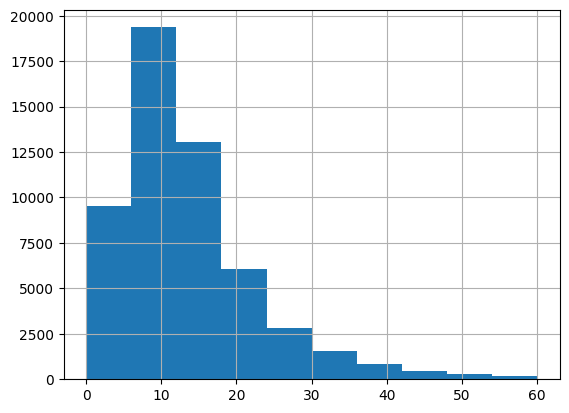

In [10]:
march_data.duration_min.hist()

In [11]:
target = "duration_min"
num_features = ["passenger_count", "trip_distance", "fare_amount", "total_amount"]
cat_features = ["PULocationID", "DOLocationID"]

In [17]:
from evidently import Report
from evidently.presets import DataDriftPreset
from evidently.metrics import QuantileValue
import datetime

In [23]:
daily_quantile_values = []

for day in pd.date_range("2024-03-01", "2024-03-31", freq="D"):
    next_day = day + pd.Timedelta(days=1)

    current_batch = march_data[
        march_data.lpep_pickup_datetime.between(day, next_day, inclusive="left")
    ]

    if current_batch.empty:
        continue

    report = Report(metrics=[
        QuantileValue(column="fare_amount", quantile=0.5)
    ])

    report.run(
        reference_data=None,
        current_data=current_batch
    )

    quantile_value = current_batch["fare_amount"].quantile(0.5)

    daily_quantile_values.append((day.date(), quantile_value))

C:\Langraph_MCP_SERVER_PRASTICS\venv\Lib\site-packages\evidently\core\datasets.py:1760: RuntimeWarning:

invalid value encountered in scalar divide

C:\Langraph_MCP_SERVER_PRASTICS\venv\Lib\site-packages\evidently\core\datasets.py:1760: RuntimeWarning:

invalid value encountered in scalar divide

C:\Langraph_MCP_SERVER_PRASTICS\venv\Lib\site-packages\evidently\core\datasets.py:1760: RuntimeWarning:

invalid value encountered in scalar divide

C:\Langraph_MCP_SERVER_PRASTICS\venv\Lib\site-packages\evidently\core\datasets.py:1760: RuntimeWarning:

invalid value encountered in scalar divide

C:\Langraph_MCP_SERVER_PRASTICS\venv\Lib\site-packages\evidently\core\datasets.py:1760: RuntimeWarning:

invalid value encountered in scalar divide

C:\Langraph_MCP_SERVER_PRASTICS\venv\Lib\site-packages\evidently\core\datasets.py:1760: RuntimeWarning:

invalid value encountered in scalar divide

C:\Langraph_MCP_SERVER_PRASTICS\venv\Lib\site-packages\evidently\core\datasets.py:1760: RuntimeWarning:

i

In [24]:
daily_quantile_values

[(datetime.date(2024, 3, 1), np.float64(13.5)),
 (datetime.date(2024, 3, 2), np.float64(12.8)),
 (datetime.date(2024, 3, 3), np.float64(14.2)),
 (datetime.date(2024, 3, 4), np.float64(12.8)),
 (datetime.date(2024, 3, 5), np.float64(12.8)),
 (datetime.date(2024, 3, 6), np.float64(12.8)),
 (datetime.date(2024, 3, 7), np.float64(13.5)),
 (datetime.date(2024, 3, 8), np.float64(12.8)),
 (datetime.date(2024, 3, 9), np.float64(13.5)),
 (datetime.date(2024, 3, 10), np.float64(14.2)),
 (datetime.date(2024, 3, 11), np.float64(12.8)),
 (datetime.date(2024, 3, 12), np.float64(12.8)),
 (datetime.date(2024, 3, 13), np.float64(13.5)),
 (datetime.date(2024, 3, 14), np.float64(14.2)),
 (datetime.date(2024, 3, 15), np.float64(13.5)),
 (datetime.date(2024, 3, 16), np.float64(13.5)),
 (datetime.date(2024, 3, 17), np.float64(13.5)),
 (datetime.date(2024, 3, 18), np.float64(12.8)),
 (datetime.date(2024, 3, 19), np.float64(13.5)),
 (datetime.date(2024, 3, 20), np.float64(12.8)),
 (datetime.date(2024, 3, 21),

In [25]:
daily_quantile_df = pd.DataFrame(daily_quantile_values, columns=["date", "fare_amount_q50"])

In [26]:
print("Maximum value of quantile=0.5 for fare_amount during March 2024:", daily_quantile_df["fare_amount_q50"].max())

Maximum value of quantile=0.5 for fare_amount during March 2024: 14.2
